In [1]:
from pycalphad import Workspace, variables as v
from pycalphad.property_framework.metaproperties import IsolatedPhase
import pandas as pd
import matplotlib.pyplot as plt
from pycalphad.property_framework.metaproperties import DormantPhase
from pycalphad.property_framework.tzero import T0
path=r"C:\Users\annac\Downloads\alzn_mey.tdb"

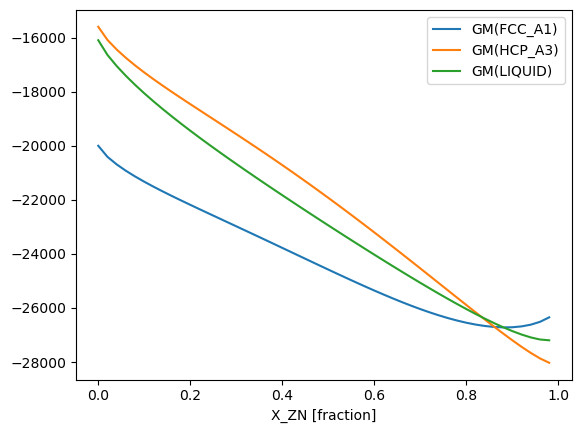

In [2]:
#Creating pycalphad Workspace object, which bundles together: a thermodynamic database (path) a list of components (['AL', 'ZN']) a list of phases to consider (['FCC_A1', 'HCP_A3', 'LIQUID']) a dictionary of conditions
#conditions dictionary: v.X('ZN'):(0,1,0.02) → vary mole fraction of Zn from 0 to 1 in steps of 0.02 v.T: 600 → temperature fixed at 600 K v.P: 101325 → pressure fixed at 1 atm v.N: 1 → total moles = 1
#This workspace defines a 1D composition sweep at fixed T and P.

wks2 = Workspace(path, ['AL', 'ZN'],
                ['FCC_A1', 'HCP_A3', 'LIQUID'],
                {v.X('ZN'):(0,1,0.02), v.T: 600, v.P:101325, v.N: 1})
#standard matplotlib
fig = plt.figure()
ax = fig.add_subplot()

#Retrieving the array of Zn mole fractions generated by the workspace.
x = wks2.get(v.X('ZN'))
#Labels the x‑axis using pycalphad’s built‑in metadata (e.g., “X(ZN) [unitless]”).
ax.set_xlabel(f"{v.X('ZN').display_name} [{v.X('ZN').display_units}]")

for phase_name in wks2.phases: #Iterate through each phase: FCC_A1, HCP_A3, LIQUID.
    # Workaround for poor starting point selection in IsolatedPhase (next two lines):
    #Makes a copy of the workspace. Restricts it to only one phase. This avoids phase competition and forces pycalphad to compute the Gibbs energy of that phase even if it is metastable.
    metastable_wks = wks2.copy() 
    metastable_wks.phases = [phase_name]
    
    #omputes Gᵐ(T,P,x) for the phase across the composition range.
    prop = IsolatedPhase(phase_name, metastable_wks)(f'GM({phase_name})') #Isolate phase creates a callable object that evaluates a property for a single phase. f'..' requests the molar Gibbs energy of that phase.
    #Renames the property so the legend looks clean.
    prop.display_name = f'GM({phase_name})'
    
    #wks2.get(prop) evaluates the property over the workspace grid. Plots Gibbs energy vs. composition for that phase.
    ax.plot(x, wks2.get(prop), label=prop.display_name)
ax.legend()

Text(0, 0.5, 'Liquid Driving Force [J / mol]')

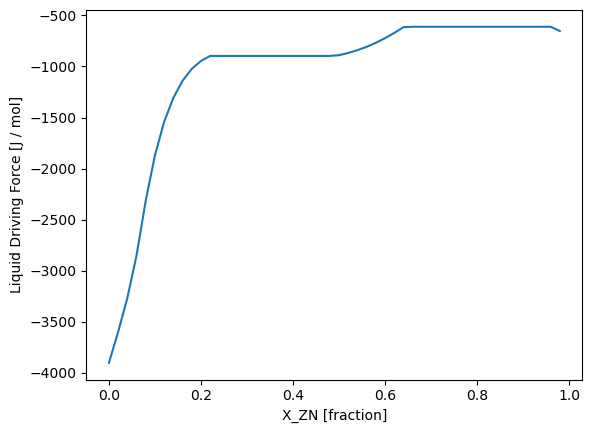

In [17]:
wks3 = Workspace(path, ['AL', 'ZN'],
                ['FCC_A1', 'HCP_A3', 'LIQUID'],
                {v.X('ZN'):(0,1,0.02), v.T: 600, v.P:101325, v.N: 1})
#Makes a full duplicate of the workspace so you can modify it without affecting the original.
metastable_liq_wks = wks3.copy()

#Restricts the workspace to only the LIQUID phase. 
#This forces pycalphad to compute properties of the liquid even when it is not the equilibrium phase. That’s essential because driving force calculations require comparing a metastable phase to the equilibrium state.
metastable_liq_wks.phases = ['LIQUID']

#Dormant phase represents a phase that is not currently stable but could become stable if conditions change. It computes the driving force for that phase to appear.
#Driving force is the difference in Gibbs energy between: the metastable phase (here: LIQUID) and the equilibrium state (whatever phase or mixture is stable at that composition)
#this line constructs the object and extracts the property that will be evaluated across the workspace grid.
liq_driving_force = DormantPhase('LIQUID', metastable_liq_wks).driving_force

liq_driving_force.display_name = 'Liquid Driving Force'

#plotting
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(wks3.get(v.X('ZN')), wks3.get(liq_driving_force))
ax.set_xlabel(f"{v.X('ZN').display_name} [{v.X('ZN').display_units}]")
ax.set_ylabel(f"{liq_driving_force.display_name} [{liq_driving_force.display_units}]")

Text(0, 0.5, 'T0(FCC_A1,HCP_A3) [kelvin]')

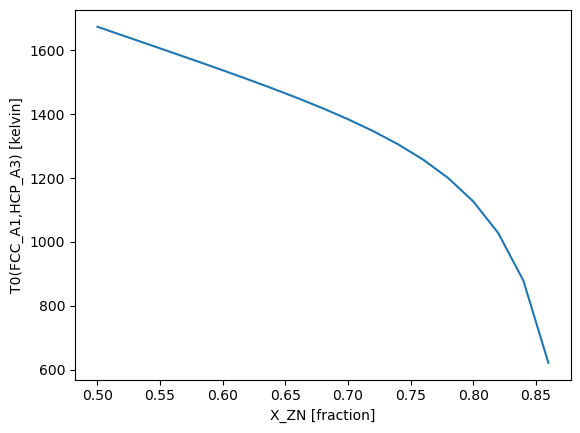

In [18]:
# For T0, conditions must be one-dimensional (step calculation)
wks4 = Workspace(path, ['AL', 'ZN'],
                ['FCC_A1', 'HCP_A3', 'LIQUID'],
                {v.X('ZN'): (0,1,0.02), v.T: 300, v.P:101325, v.N: 1})
#creates a T₀ object representing the T₀ curve between the phases FCC_A1 and HCP_A3.
#It is the temperature at which the two phases have equal Gibbs energy at the same composition.
#Compute the temperature where FCC_A1 and HCP_A3 have equal Gibbs energy across the composition range defined in wks4.
tzero = T0('FCC_A1', 'HCP_A3', wks4)
tzero.maximum_value = 1700 # set temperature limit, basically avoids divergencies in the model and keeps thing real

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(wks4.get(v.X('ZN')), wks4.get(tzero))
ax.set_xlabel(f"{v.X('ZN').display_name} [{v.X('ZN').display_units}]")
ax.set_ylabel(f"{tzero} [{tzero.display_units}]")